In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_groq import ChatGroq
from typing_extensions import TypedDict, Annotated
from dotenv import load_dotenv
load_dotenv()

llm = ChatGroq(
    model="qwen/qwen3.6-27b",
    profile={
        "max_input_tokens":131_000
    }
)

# create a state type
class State(TypedDict):
    messages: Annotated[list, add_messages]

# create node (say chatbot)
def chatbot(state: State)->str:
    return {"messages": [llm.invoke(state["messages"])]}

# create graph builder
graph_builder = StateGraph(State)

# bind with nodes
graph_builder.add_node("Chat_Bot_Node", chatbot)

# craete edges
graph_builder.add_edge(START, "Chat_Bot_Node")
graph_builder.add_edge("Chat_Bot_Node", END)

# compile the graph
graph = graph_builder.compile()

In [ ]:
llm.invoke("test")

In [ ]:
# Display the Graph

from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_png()
    )
)

In [ ]:
res = graph.invoke({
    "messages": "hi"
})
res
# res["messages"][-1].content

In [ ]:
# print(res["messages"][-1].content)
graph

In [ ]:
# Streaming the graph output
for event in graph.stream({"messages": "provide a medium paragraph on 'AIML'"}, stream_mode="updates"):
    print(event)
    for value in event.values():
        print(value["messages"][-1].content)

In [ ]:
# Streaming the graph output
for chunk, meta  in graph.stream({"messages": "provide a medium paragraph on 'AIML'"}, stream_mode="messages"):
    print(chunk.content, flush=True)

# Langgraph with tool (Runnable Binding )

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages

from langchain.chat_models import init_chat_model
from langchain_core.messages import BaseMessage
from langchain_tavily import TavilySearch
from langchain.tools import tool

from typing_extensions import TypedDict, Annotated
from dotenv import load_dotenv
load_dotenv()

# create llm or agent 
llm = init_chat_model(
    "openrouter/free",
    model_provider="openrouter"
)

# create state 
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# create tool
tavily_tool = TavilySearch(max_results=3, time_range="day")

@tool
def isPrime_tool(num1:int, num2:int)->bool:
    """
    This Tool validates whether a number (num1) is prime factore of number (num2) or not
    
    Args:
        num1(int): the first number to check whether its a prime or not
        num2(int): second number,whther a num1 is prime factors of num2
    Returns:
        bool: if num2 is prime and factor of num2 then it returns true else false 
    """
    return True

tools = [tavily_tool, isPrime_tool]


# llm with tools node
def llm_with_tool_node(state: State):
    llm_with_tool = llm.bind_tools(tools)
    resp = {"messages": [llm_with_tool.invoke(state["messages"])]}
    return resp

# create graph builder
graph_builder = StateGraph(State)

graph_builder.add_node("llm_with_tool", llm_with_tool_node)
graph_builder.add_node("tools", ToolNode(tools))


graph_builder.add_edge(START, "llm_with_tool")
graph_builder.add_edge("llm_with_tool", "tools")
graph_builder.add_conditional_edges(
    "llm_with_tool",
    tools_condition
)
graph_builder.add_edge("tools", END)
graph = graph_builder.compile()
graph


# ReAct Architecture

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages

from langchain.chat_models import init_chat_model
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_tavily import TavilySearch
from langchain.tools import tool

from typing_extensions import TypedDict, Annotated
from dotenv import load_dotenv
load_dotenv()

# create llm or agent 
# llm = init_chat_model(
#     "inclusionai/ling-3.0-flash-fin:free",
#     model_provider="openrouter"
# )

llm = init_chat_model("openai/gpt-oss-20b", model_provider="groq")

# create state 
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# create tool
tavily_tool = TavilySearch(max_results=3, time_range="day")

@tool
def isPrime_tool(num1:int, num2:int)->bool:
    """
    This Tool validates whether a number (num1) is prime factore of number (num2) or not
    
    Args:
        num1(int): the first number to check whether its a prime or not
        num2(int): second number,whther a num1 is prime factors of num2
    Returns:
        bool: if num2 is prime and factor of num2 then it returns true else false 
    """
    return True

tools = [tavily_tool, isPrime_tool]


# llm with tools node
def llm_with_tool_node(state: State):
    llm_with_tool = llm.bind_tools(tools)
    resp = {"messages": [llm_with_tool.invoke(state["messages"])]}
    return resp

# create graph builder
graph_builder = StateGraph(State)

graph_builder.add_node("llm_with_tool", llm_with_tool_node)
graph_builder.add_node("tools", ToolNode(tools))


graph_builder.add_edge(START, "llm_with_tool")
graph_builder.add_conditional_edges(
    "llm_with_tool",
    tools_condition
)
graph_builder.add_edge("tools", "llm_with_tool")
graph = graph_builder.compile()
graph


In [ ]:
resp = graph.invoke({
    "messages": [HumanMessage(content="what is current price of gold and  then is 10 a current prime number prime number")]
})

In [ ]:
for msg in  resp["messages"]:
    msg.pretty_print()

# Adding Memory In Agentic Graph

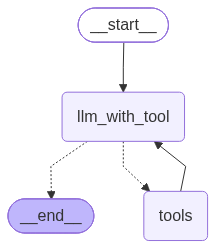

In [48]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

from langchain.chat_models import init_chat_model
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_tavily import TavilySearch
from langchain.tools import tool

from typing_extensions import TypedDict, Annotated
from dotenv import load_dotenv
load_dotenv()

# create llm or agent 
llm = init_chat_model("openai/gpt-oss-20b", model_provider="groq")
memory = InMemorySaver()

# create state 
class State(TypedDict):
    messages: Annotated[list, add_messages]

# create tool
tavily_tool = TavilySearch(max_results=3, time_range="day")

@tool
def isPrime_tool(num1:int, num2:int)->bool:
    """
    This Tool validates whether a number (num1) is prime factore of number (num2) or not
    
    Args:
        num1(int): the first number to check whether its a prime or not
        num2(int): second number,whther a num1 is prime factors of num2
    Returns:
        bool: if num2 is prime and factor of num2 then it returns true else false 
    """
    return True

tools = [tavily_tool, isPrime_tool]
llm_with_tool = llm.bind_tools(tools)

SYSTEM_PROMPT = """
You are a helpful assistant.

Use the search tool when current or up-to-date information is required.

After receiving a useful search result, answer the user directly.
Do not perform another search for the same question unless the
previous result is clearly insufficient or unreliable.
"""

# llm with tools node
def llm_with_tool_node(state: State):
    resp = {"messages": [llm_with_tool.invoke([SystemMessage(SYSTEM_PROMPT), *state["messages"]])]}
    return resp

# create graph builder
graph_builder = StateGraph(State)

graph_builder.add_node("llm_with_tool", llm_with_tool_node)
graph_builder.add_node("tools", ToolNode(tools))


graph_builder.add_edge(START, "llm_with_tool")
graph_builder.add_conditional_edges(
    "llm_with_tool",
    tools_condition
)
graph_builder.add_edge("tools", "llm_with_tool")
graph = graph_builder.compile(checkpointer=memory)
graph


In [49]:
config = {
    "configurable":{
        "thread_id": "4"
    },
    "recursion_limit": 10
}
resp = graph.invoke({
    "messages": [
        HumanMessage(content="my name is Vivek")
    ]
}, config=config)

In [56]:
config = {
    "configurable":{
        "thread_id": "5"
    },
    "recursion_limit": 10
}
resp = graph.invoke({
    "messages": [
        HumanMessage(content="what is my name")
    ]
}, config=config)
for msg in resp["messages"]:
    msg.pretty_print()

================================ Human Message =================================

what is my name
================================== Ai Message ==================================

I’m sorry, but I don’t know your name. Could you let me know what you’d like me to call you?


# Streaming 

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model
from langchain.tools import tool

from typing_extensions import TypedDict, Annotated
from dotenv import load_dotenv
load_dotenv()

# create llm or agent 
llm = init_chat_model("openai/gpt-oss-20b", model_provider="groq")
memory = MemorySaver()

# state
class State(TypedDict):
    messages: Annotated[list, add_messages]

def llm_tool_node(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# create graph builder
graph_builder = StateGraph(State)

graph_builder.add_node("llm", llm_tool_node)
graph_builder.add_edge(START, "llm")
graph_builder.add_edge("llm", END)

graph = graph_builder.compile(checkpointer=memory)
graph



NameError: name 'add_messages' is not defined